# Effects of Sediment and Water Column Acidification on Benthic Invertebrates

**Domain:** Marine Ecology · Ocean Acidification  
**Datasets:** Laboratory experimental data — University of New Brunswick / Huntsman Marine Science Centre  
**Language:** R  

---

## Study Overview

Coastal benthic invertebrates experience high natural variability in seawater and sediment pH, and anthropogenic ocean acidification is expected to further reduce pH in these environments. This analysis examines how water column acidification and sediment acidification — individually and in combination — affect growth, survival, and burrowing behaviour of four species of intertidal invertebrates from the Bay of Fundy, Canada.

A third experiment tests whether GABA\u2082 receptor disruption by the neuroinhibitor gabazine is the physiological mechanism underlying the burrowing response to reduced sediment pH.

**Central question:** Do water column acidification, sediment acidification, and GABA\u2082 receptor disruption affect the growth, survival, and burrowing behaviour of benthic invertebrates, and does the response vary taxonomically?

**Species studied:**
- *Mya arenaria* — juvenile soft-shell clam (2017 only)
- *Tritia obsoleta* — adult mud snail
- *Corophium volutator* — adult amphipod
- *Limecola balthica* — juvenile Baltic clam (GABA\u2082 experiment only)

---

**Notebook structure:**
1. Setup
2. Data ingestion
3. Sediment pH profiles
4. Water column acidification — growth and survival
5. Sediment acidification — burrowing behaviour (2017)
6. Sediment acidification — burrowing behaviour (2018)
7. GABA\u2082 experiment — gabazine × sediment pH
8. Results summary

---

**Citation:** McGarrigle, S.A., Bishop, M.M., Dove, S.L., Hunt, H.L. (2023). Effects of sediment and water column acidification on growth, survival, burrowing behaviour, and GABA\u2082 receptor function of benthic invertebrates. *Journal of Experimental Marine Biology and Ecology*, 566, 151918. https://doi.org/10.1016/j.jembe.2023.151918

---
*academic_projects - Samantha McGarrigle*

## 1. Setup

In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(ggthemes)
library(nlme)       # lme()
library(car)        # Anova(), leveneTest()
library(broom)

# ── Species and treatment display labels ──────────────────────────────────
Species.labs <- c("M. arenaria", "C. volutator", "T. obsoleta")
names(Species.labs) <- c("Clam", "Corophium", "Snail")

Species.labs.mac <- c("L. balthica", "C. volutator", "T. obsoleta")
names(Species.labs.mac) <- c("Limecola", "Corophium", "Snail")

Sed.labs   <- c("Acidified Sed", "Control Sed")
names(Sed.labs) <- c("Acidified", "Control")

water.labs <- c("Acidified Water", "Control Water")
names(water.labs) <- c("Acidified", "Control")

gaba.labs  <- c("Gabazine Absent", "Gabazine Present")
names(gaba.labs) <- c("N", "Y")

# ── Global significance level ─────────────────────────────────────────────
ALPHA <- 0.05

cat("Setup complete.\n")

Warning message:
"package 'dplyr' was built under R version 4.4.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'ggpubr' was built under R version 4.4.3"

Attaching package: 'nlme'


The following object is masked from 'package:dplyr':

    collapse


Warning message:
"package 'car' was built under R version 4.4.3"
Loading required package: carData

Warning message:
"package 'carData' was built under R version 4.4.3"

Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode


Warning message:
"package 'broom' was built under R version 4.4.3"


Setup complete.


## 2. Data Ingestion

Ten CSV files are loaded from the working directory. Place all data files in the same folder as this notebook before running.

| File | Contents | Experiment |
|---|---|---|
| `17_burrow.csv` | Burrowing counts by burrow type, all species | Sediment acidification 2017 |
| `17_burrow_binary.csv` | Burrowing proportions with arcsine transform, all species | Sediment acidification 2017 |
| `18_burrow.csv` | Burrowing counts by burrow type, all species | Sediment acidification 2018 |
| `18_burrow_binary.csv` | Burrowing proportions, all species | Sediment acidification 2018 |
| `17_burrowgaba.csv` | Burrowing proportions × gabazine treatment | GABA\u2082 experiment 2017 |
| `17_snailweisur.csv` | *T. obsoleta* survival, weight, length per replicate | Water column acidification 2017 |
| `17_clamweisur.csv` | *M. arenaria* survival, weight, length per replicate | Water column acidification 2017 |
| `18_snailweisur.csv` | *T. obsoleta* survival, weight, length per replicate | Water column acidification 2018 |
| `17_sedpH.csv` | Sediment pH by depth, treatment, container | Abiotic characterisation 2017 |
| `18_sedpH.csv` | Sediment pH by depth, treatment, container | Abiotic characterisation 2018 |

In [2]:
# ── Burrowing — sediment × water acidification ────────────────────────────
bur17  <- read.csv("data/17_burrow.csv",        header = TRUE)
bur17b <- read.csv("data/17_burrow_binary.csv", header = TRUE)
bur18  <- read.csv("data/18_burrow.csv",        header = TRUE)
bur18b <- read.csv("data/18_burrow_binary.csv", header = TRUE)

# ── Burrowing — GABAA experiment ──────────────────────────────────────────
burgab <- read.csv("data/17_burrowgaba.csv",    header = TRUE)

# ── Growth and survival — water column acidification ─────────────────────
snailsurwei17 <- read.csv("data/17_snailweisur.csv", header = TRUE)
clamsurwei17  <- read.csv("data/17_clamweisur.csv",  header = TRUE)
snailsurwei18 <- read.csv("data/18_snailweisur.csv", header = TRUE)

# ── Sediment pH profiles ──────────────────────────────────────────────────
sed17 <- read.csv("data/17_sedpH.csv", header = TRUE)
sed18 <- read.csv("data/18_sedpH.csv", header = TRUE)

cat("All files loaded.\n")

All files loaded.


In [3]:
# ── Factor coercion and derived variables — burrowing 2017 ────────────────
bur17$Burrow_type <- factor(bur17$Burrow_type, levels = c("Not", "Partial", "Complete"))
bur17$Sediment    <- as.factor(bur17$Sediment)
bur17$Water       <- as.factor(bur17$Water)

bur17b$Burrow_type <- factor(bur17b$Burrow_type, levels = c("Not", "Complete"))
bur17b$Sediment    <- as.factor(bur17b$Sediment)
bur17b$Water       <- as.factor(bur17b$Water)
bur17b$Species     <- as.factor(bur17b$Species)
bur17b$trans_burr  <- asin(sqrt(bur17b$Burrow_prop))  # arcsine-sqrt transform

# ── Factor coercion and derived variables — burrowing 2018 ────────────────
bur18$Burrow_type <- factor(bur18$Burrow_type, levels = c("Not", "Partial", "Complete"))
bur18$Sediment    <- as.factor(bur18$Sediment)
bur18$Water       <- as.factor(bur18$Water)

bur18b$Burrow_type <- factor(bur18b$Burrow_type, levels = c("Not", "Complete"))
bur18b$Sediment    <- as.factor(bur18b$Sediment)
bur18b$Water       <- as.factor(bur18b$Water)
bur18b$Species     <- as.factor(bur18b$Species)
bur18b$trans_burr  <- asin(sqrt(bur18b$Burrow_prop))

# ── Factor coercion — GABAA experiment ───────────────────────────────────
burgab$Burrow_type <- factor(burgab$Burrow_type, levels = c("Not", "Complete"))
burgab$GabaPres    <- as.factor(burgab$GabaPres)
burgab$Species     <- as.factor(burgab$Species)
burgab$Water       <- as.factor(burgab$Water)
burgab$trans_burr  <- asin(sqrt(burgab$Burr_prop))

# ── Derived per-individual means — snail 2017 ────────────────────────────
snailsurwei17$Treatment    <- as.factor(snailsurwei17$Treatment)
snailsurwei17$weigh_start1 <- snailsurwei17$weigh_start / snailsurwei17$num_start
snailsurwei17$weigh_end1   <- snailsurwei17$weigh_end   / snailsurwei17$num_recov
snailsurwei17$leng_start1  <- snailsurwei17$leng_start  / snailsurwei17$num_start
snailsurwei17$leng_end1    <- snailsurwei17$leng_end    / snailsurwei17$num_recov
snailsurwei17$snail_surv   <- snailsurwei17$snail_surv  / 100
snailsurwei17$log_weigh    <- log(snailsurwei17$weigh_end1 / snailsurwei17$weigh_start1)
snailsurwei17$log_leng     <- log(snailsurwei17$leng_end1  / snailsurwei17$leng_start1)

# ── Derived per-individual means — clam 2017 ─────────────────────────────
clamsurwei17$Treatment    <- as.factor(clamsurwei17$Treatment)
clamsurwei17$weigh_start1 <- clamsurwei17$weigh_start  / clamsurwei17$num_start
clamsurwei17$weigh_end1   <- clamsurwei17$weigh_end    / clamsurwei17$num_recov
clamsurwei17$leng_start1  <- clamsurwei17$leng_start   / clamsurwei17$num_start
clamsurwei17$leng_final1  <- clamsurwei17$leng_final   / clamsurwei17$num_recov
clamsurwei17$chang_weigh  <- clamsurwei17$chang_weigh  / 100
clamsurwei17$log_weigh    <- log(clamsurwei17$weigh_end1  / clamsurwei17$weigh_start1)
clamsurwei17$log_leng     <- log(clamsurwei17$leng_final1 / clamsurwei17$leng_start1)

# ── Derived per-individual means — snail 2018 ────────────────────────────
snailsurwei18$Treatment    <- as.factor(snailsurwei18$Treatment)
snailsurwei18$weigh_start1 <- snailsurwei18$weigh_start  / snailsurwei18$Indiv_start
snailsurwei18$weigh_end1   <- snailsurwei18$weigh_end    / snailsurwei18$Indiv_end
snailsurwei18$leng_start1  <- snailsurwei18$leng_start   / snailsurwei18$Indiv_start
snailsurwei18$leng_end1    <- snailsurwei18$leng_end     / snailsurwei18$Indiv_end
snailsurwei18$Surv         <- snailsurwei18$Surv         / 100
snailsurwei18$log_weigh    <- log(snailsurwei18$weigh_end1 / snailsurwei18$weigh_start1)
snailsurwei18$log_leng     <- log(snailsurwei18$leng_end1  / snailsurwei18$leng_start1)

# ── Sediment pH factors ───────────────────────────────────────────────────
sed17$Treatment <- as.factor(sed17$Treatment)
sed17$Depth     <- as.factor(sed17$Depth)
sed18$Treatment <- as.factor(sed18$Treatment)
sed18$Depth     <- as.factor(sed18$Depth)

cat("Data preparation complete.\n")

Data preparation complete.


In [4]:
# ── Species-level subsets — burrowing 2017 ────────────────────────────────
bur17b_comp  <- filter(bur17b, Burrow_type == "Complete")
bur17_coro   <- filter(bur17b, Species == "Corophium", Burrow_type == "Complete")
bur17_clam   <- filter(bur17b, Species == "Clam",      Burrow_type == "Complete")
bur17_snail  <- filter(bur17b, Species == "Snail",     Burrow_type == "Complete")

# ── Species-level subsets — burrowing 2018 ────────────────────────────────
bur18b_comp  <- filter(bur18b, Burrow_type == "Complete")
bur18_coro   <- filter(bur18b, Species == "Corophium", Burrow_type == "Complete")
bur18_snail  <- filter(bur18b, Species == "Snail",     Burrow_type == "Complete")

# ── Species-level subsets — GABAA experiment ─────────────────────────────
burgab_comp  <- filter(burgab, Burrow_type == "Complete")
burgab_snail <- filter(burgab, Species == "Snail",      Burrow_type == "Complete")
burgab_coro  <- filter(burgab, Species == "Corophium",  Burrow_type == "Complete")
burgab_mac   <- filter(burgab, Species == "Limecola",   Burrow_type == "Complete")

cat("Subsets created.\n")

Subsets created.


## 3. Sediment pH Profiles

Sediment pH was measured at 1 cm depth intervals from the surface to 4 cm in both acidified and control sediment treatments in 2017 and 2018. These profiles confirm that the CO\u2082 addition protocol successfully differentiated sediment pH between treatments and characterise the pH conditions experienced by burrowing animals.

Target values: 2017 control = 7.37 \u00b1 0.15, acidified = 6.65 \u00b1 0.19; 2018 control = 7.10 \u00b1 0.16, acidified = 6.48 \u00b1 0.14.

In [5]:
# ── Sediment pH summary by treatment and depth ────────────────────────────
cat("--- 2017 sediment pH (mean and range by treatment × depth) ---\n")
sed17 %>%
    group_by(Treatment, Depth) %>%
    summarise(
        mean  = round(mean(pH), 2),
        range = round(max(pH) - min(pH), 2),
        .groups = "drop"
    ) %>%
    print()

cat("\n--- 2018 sediment pH (mean and range by treatment × depth) ---\n")
sed18 %>%
    group_by(Treatment, Depth) %>%
    summarise(
        mean  = round(mean(pH), 2),
        range = round(max(pH) - min(pH), 2),
        .groups = "drop"
    ) %>%
    print()

--- 2017 sediment pH (mean and range by treatment × depth) ---
# A tibble: 10 × 4
   Treatment Depth  mean range
   <fct>     <fct> <dbl> <dbl>
 1 Acidified 0      7.24  0.79
 2 Acidified 1      7.16  0.8 
 3 Acidified 2      7.09  0.79
 4 Acidified 3      7.05  0.8 
 5 Acidified 4      7.01  0.71
 6 Control   0      7.5   0.9 
 7 Control   1      7.42  1.02
 8 Control   2      7.33  0.98
 9 Control   3      7.26  0.96
10 Control   4      7.25  0.87

--- 2018 sediment pH (mean and range by treatment × depth) ---
# A tibble: 10 × 4
   Treatment Depth  mean range
   <fct>     <fct> <dbl> <dbl>
 1 Acidified 0      7.51  0.57
 2 Acidified 1      7.45  0.59
 3 Acidified 2      7.35  0.5 
 4 Acidified 3      7.1   3.11
 5 Acidified 4      7.26  0.49
 6 Control   0      7.52  0.6 
 7 Control   1      7.48  0.52
 8 Control   2      7.4   0.53
 9 Control   3      7.37  0.52
10 Control   4      7.34  0.46


Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."


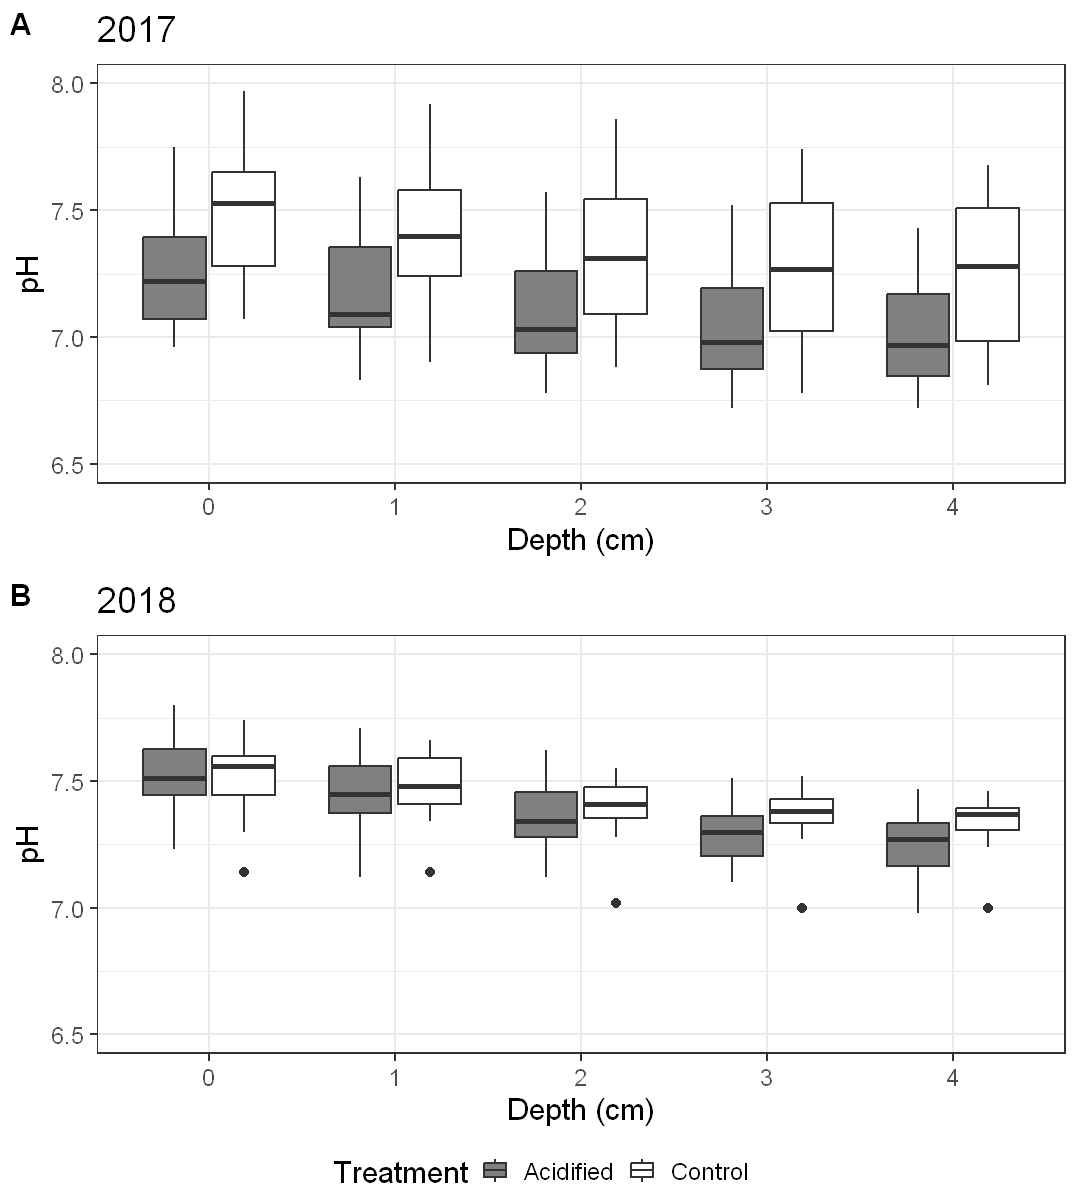

In [6]:
options(repr.plot.width = 9, repr.plot.height = 10)

# ── Figure: sediment pH profiles 2017 and 2018 ───────────────────────────
p_sed17 <- ggplot(sed17, aes(x = Depth, y = pH, fill = Treatment)) +
    geom_boxplot() +
    xlab("Depth (cm)") +
    ylab("pH") +
    ylim(6.5, 8.0) +
    scale_fill_grey(start = 0.5, end = 1.0) +
    theme_bw(base_size = 18) +
    ggtitle("2017")

p_sed18 <- ggplot(sed18, aes(x = Depth, y = pH, fill = Treatment)) +
    geom_boxplot() +
    xlab("Depth (cm)") +
    ylab("pH") +
    ylim(6.5, 8.0) +
    scale_fill_grey(start = 0.5, end = 1.0) +
    theme_bw(base_size = 18) +
    ggtitle("2018")

ggarrange(p_sed17, p_sed18,
          labels      = c("A", "B"),
          ncol        = 1, nrow = 2,
          font.label  = list(size = 18),
          common.legend = TRUE, legend = "bottom")

### Interpretation

Sediment pH was successfully differentiated between acidified and control treatments at all measured depths in both trial years. The pH profiles confirm that CO\u2082 addition uniformly reduced porewater pH across the top 4 cm of sediment — the zone in which all experimental species burrow. Treatment pH values are consistent with the range measured on the Little Lepreau mudflat (Clements and Hunt, 2018), supporting the ecological relevance of the experimental conditions.

## 4. Water Column Acidification — Growth and Survival

A 6-week water column acidification experiment examined the effects of reduced-pH seawater (control pH \u2248 7.87; acidified pH \u2248 7.65) on shell length, wet weight, and survival of *M. arenaria* (2017 only) and *T. obsoleta* (2017 and 2018). Length and weight are expressed as the log ratio of final to initial per-individual container means to correct for non-normality and differences in starting values.

**Statistical approach:** Two-sample t-tests (2017); linear mixed effects models with header tank replicate as a random effect (2018).

In [7]:
# ── Assumption checks — snail 2017 ────────────────────────────────────────
cat("=== T. obsoleta 2017 — assumption checks ===\n")
cat("\nShapiro-Wilk: log weight change\n")
print(shapiro.test(snailsurwei17$log_weigh))
cat("\nShapiro-Wilk: log length change\n")
print(shapiro.test(snailsurwei17$log_leng))
cat("\nShapiro-Wilk: number recovered\n")
print(shapiro.test(snailsurwei17$num_recov))

=== T. obsoleta 2017 — assumption checks ===

Shapiro-Wilk: log weight change

	Shapiro-Wilk normality test

data:  snailsurwei17$log_weigh
W = 0.91916, p-value = 0.09546


Shapiro-Wilk: log length change

	Shapiro-Wilk normality test

data:  snailsurwei17$log_leng
W = 0.90286, p-value = 0.04667


Shapiro-Wilk: number recovered

	Shapiro-Wilk normality test

data:  snailsurwei17$num_recov
W = 0.54544, p-value = 8.422e-07



In [8]:
# ── 2017 t-tests: T. obsoleta ─────────────────────────────────────────────
cat("=== T. obsoleta 2017 — t-tests ===\n\n")

cat("Log length change:\n")
print(t.test(log_leng   ~ Treatment, data = snailsurwei17))

cat("\nLog weight change:\n")
print(t.test(log_weigh  ~ Treatment, data = snailsurwei17))

cat("\nNumber recovered (survival):\n")
print(t.test(num_recov  ~ Treatment, data = snailsurwei17))

=== T. obsoleta 2017 — t-tests ===

Log length change:

	Welch Two Sample t-test

data:  log_leng by Treatment
t = -3.2551, df = 13.272, p-value = 0.006118
alternative hypothesis: true difference in means between group Acidified and group Control is not equal to 0
95 percent confidence interval:
 -0.34850894 -0.07079653
sample estimates:
mean in group Acidified   mean in group Control 
            -0.16681311              0.04283962 


Log weight change:

	Welch Two Sample t-test

data:  log_weigh by Treatment
t = 0.5066, df = 17.992, p-value = 0.6186
alternative hypothesis: true difference in means between group Acidified and group Control is not equal to 0
95 percent confidence interval:
 -0.03504434  0.05731450
sample estimates:
mean in group Acidified   mean in group Control 
             0.07419200              0.06305692 


Number recovered (survival):

	Welch Two Sample t-test

data:  num_recov by Treatment
t = 0.55709, df = 15.736, p-value = 0.5853
alternative hypothesis: true 

In [9]:
# ── 2017 t-tests: M. arenaria ─────────────────────────────────────────────
cat("=== M. arenaria 2017 — t-tests ===\n\n")

cat("Log length change:\n")
print(t.test(log_leng   ~ Treatment, data = clamsurwei17))

cat("\nLog weight change:\n")
print(t.test(log_weigh  ~ Treatment, data = clamsurwei17))

cat("\nNumber recovered (survival):\n")
print(t.test(num_recov  ~ Treatment, data = clamsurwei17))

=== M. arenaria 2017 — t-tests ===

Log length change:

	Welch Two Sample t-test

data:  log_leng by Treatment
t = 1.3359, df = 17.72, p-value = 0.1985
alternative hypothesis: true difference in means between group Acidified and group Control is not equal to 0
95 percent confidence interval:
 -0.1052909  0.4719103
sample estimates:
mean in group Acidified   mean in group Control 
             0.19389079              0.01058109 


Log weight change:

	Welch Two Sample t-test

data:  log_weigh by Treatment
t = 0.95139, df = 11.719, p-value = 0.3606
alternative hypothesis: true difference in means between group Acidified and group Control is not equal to 0
95 percent confidence interval:
 -0.1377535  0.3502980
sample estimates:
mean in group Acidified   mean in group Control 
              0.5687976               0.4625254 


Number recovered (survival):

	Welch Two Sample t-test

data:  num_recov by Treatment
t = -0.89309, df = 16.616, p-value = 0.3846
alternative hypothesis: true differ

In [10]:
# ── 2018 linear mixed models: T. obsoleta ────────────────────────────────
# Rep (header tank replicate) included as random effect to address
# pseudoreplication from the nested 2018 design (Cornwall & Hurd, 2013)
cat("=== T. obsoleta 2018 — linear mixed effects models ===\n\n")

weigh18_snail.lme <- lme(log_weigh  ~ Treatment, random = ~1|Rep,
                         na.action = na.exclude, data = snailsurwei18)
cat("Log weight change:\n")
print(car::Anova(weigh18_snail.lme, type = "III"))

leng18_snail.lme  <- lme(log_leng   ~ Treatment, random = ~1|Rep,
                         na.action = na.exclude, data = snailsurwei18)
cat("\nLog length change:\n")
print(car::Anova(leng18_snail.lme, type = "III"))

surv18_snail.lme  <- lme(Indiv_end  ~ Treatment, random = ~1|Rep,
                         na.action = na.exclude, data = snailsurwei18)
cat("\nIndividuals recovered (survival):\n")
print(car::Anova(surv18_snail.lme, type = "III"))

=== T. obsoleta 2018 — linear mixed effects models ===

Log weight change:
Analysis of Deviance Table (Type III tests)

Response: log_weigh
              Chisq Df Pr(>Chisq)    
(Intercept) 32.7660  1  1.039e-08 ***
Treatment    0.5375  1     0.4635    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Log length change:
Analysis of Deviance Table (Type III tests)

Response: log_leng
             Chisq Df Pr(>Chisq)
(Intercept) 0.0432  1     0.8354
Treatment   1.6852  1     0.1942

Individuals recovered (survival):
Analysis of Deviance Table (Type III tests)

Response: Indiv_end
                 Chisq Df Pr(>Chisq)    
(Intercept) 9.4879e+29  1     <2e-16 ***
Treatment   2.2000e+00  1      0.138    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."
Warning message:
"Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


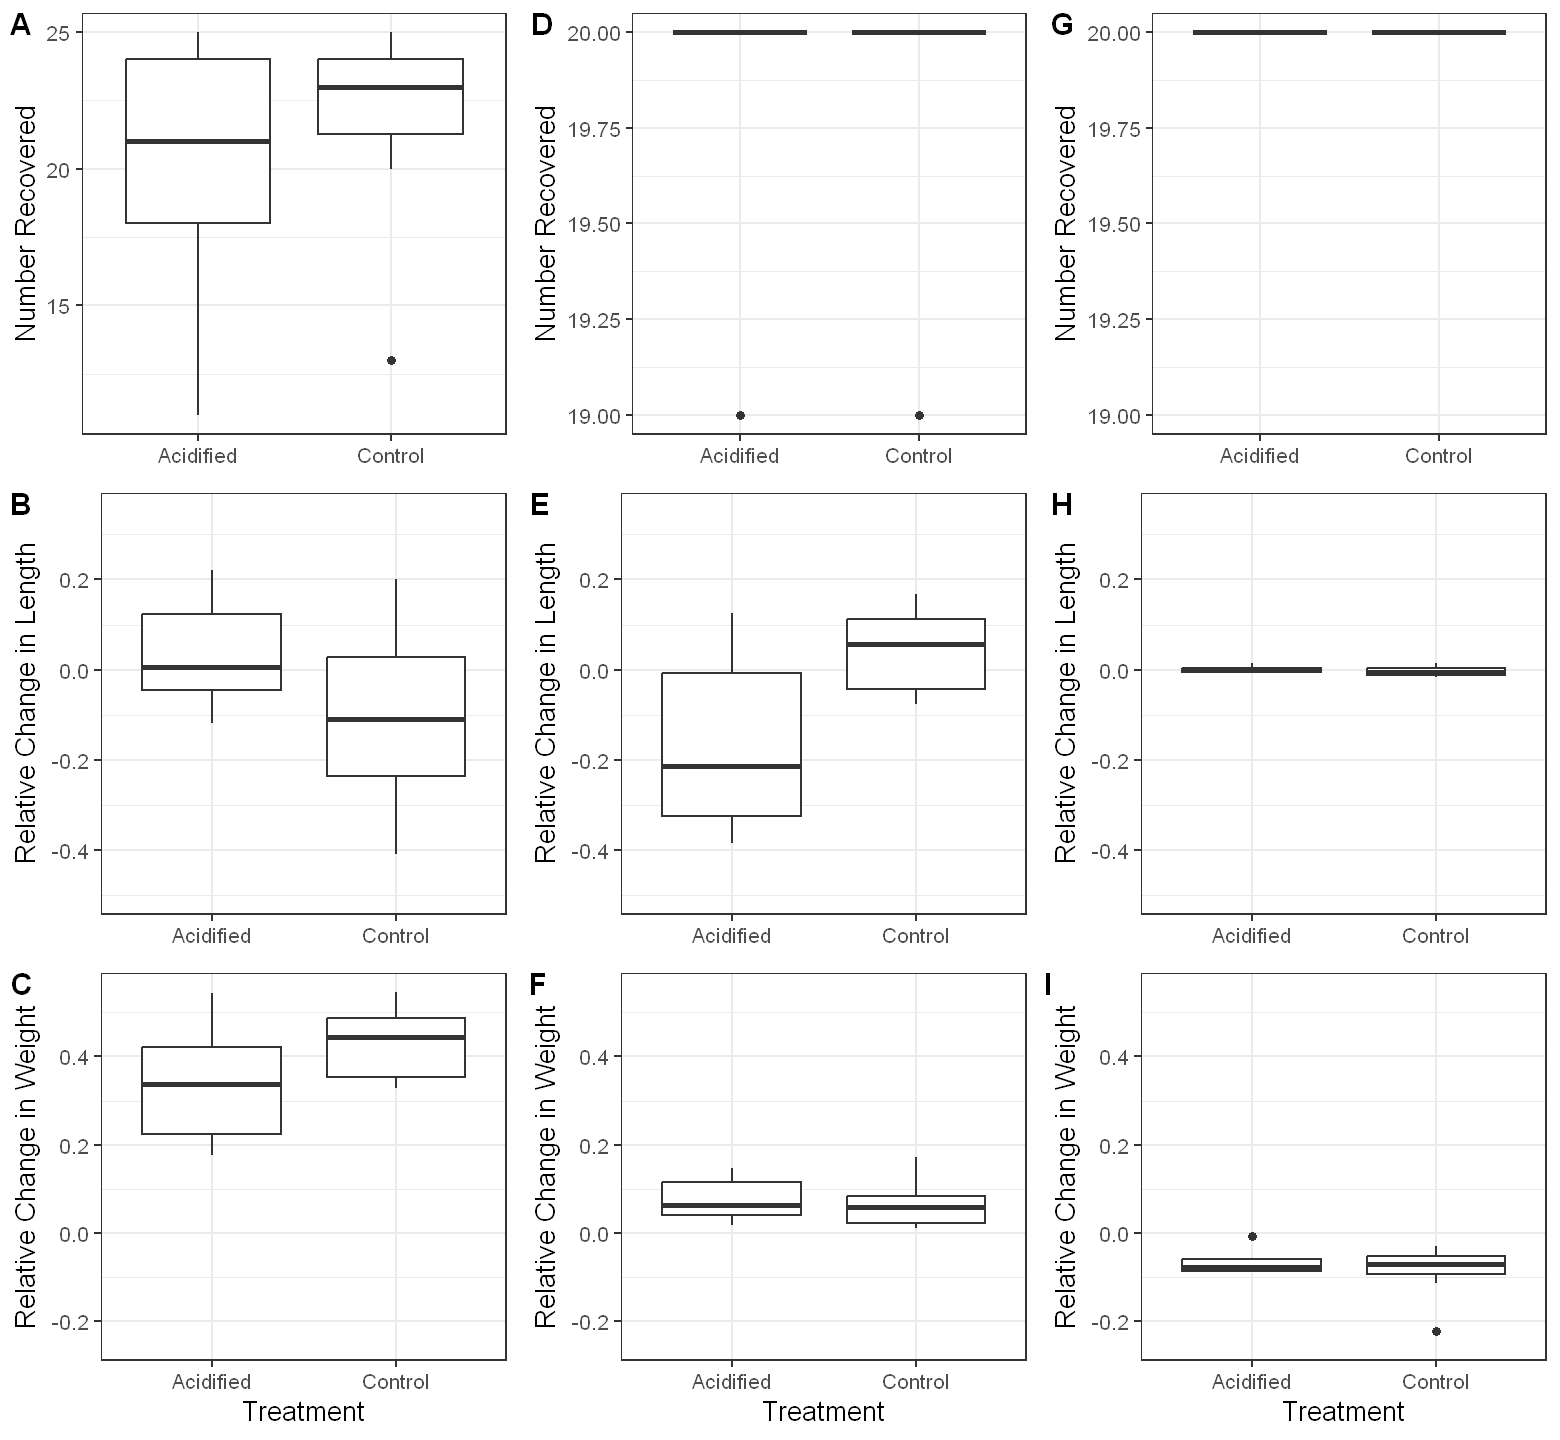

In [11]:
options(repr.plot.width = 13, repr.plot.height = 12)

# ── Descriptive summary panels — Figure: survival, length, weight ─────────
# Rows: metric (survival, length change, weight change)
# Columns: M. arenaria 2017 | T. obsoleta 2017 | T. obsoleta 2018

clamsur17  <- ggplot(clamsurwei17,  aes(x = Treatment, y = num_recov)) +
    geom_boxplot() + ylab("Number Recovered") + ylim(NA, 25) +
    theme_bw(base_size = 16)

snailsur17 <- ggplot(snailsurwei17, aes(x = Treatment, y = num_recov)) +
    geom_boxplot() + ylab("Number Recovered") + ylim(NA, 20) +
    theme_bw(base_size = 16)

snailsur18 <- ggplot(snailsurwei18, aes(x = Treatment, y = Indiv_end)) +
    geom_boxplot() + ylab("Number Recovered") + ylim(19, 20) +
    theme_bw(base_size = 16)

clamleng17  <- ggplot(clamsurwei17,  aes(x = Treatment, y = log_leng)) +
    geom_boxplot() + ylab("Relative Change in Length") + ylim(-0.5, 0.35) +
    theme_bw(base_size = 16)

snailleng17 <- ggplot(snailsurwei17, aes(x = Treatment, y = log_leng)) +
    geom_boxplot() + ylab("Relative Change in Length") + ylim(-0.5, 0.35) +
    theme_bw(base_size = 16)

snailleng18 <- ggplot(snailsurwei18, aes(x = Treatment, y = log_leng)) +
    geom_boxplot() + ylab("Relative Change in Length") + ylim(-0.5, 0.35) +
    theme_bw(base_size = 16)

clamwei17  <- ggplot(clamsurwei17,  aes(x = Treatment, y = log_weigh)) +
    geom_boxplot() + ylab("Relative Change in Weight") + ylim(-0.25, 0.55) +
    theme_bw(base_size = 16)

snailwei17 <- ggplot(snailsurwei17, aes(x = Treatment, y = log_weigh)) +
    geom_boxplot() + ylab("Relative Change in Weight") + ylim(-0.25, 0.55) +
    theme_bw(base_size = 16)

snailwei18 <- ggplot(snailsurwei18, aes(x = Treatment, y = log_weigh)) +
    geom_boxplot() + ylab("Relative Change in Weight") + ylim(-0.25, 0.55) +
    theme_bw(base_size = 16)

ggarrange(
    clamsur17  + rremove("xlab"),
    snailsur17 + rremove("xlab"),
    snailsur18 + rremove("xlab"),
    clamleng17 + rremove("xlab"),
    snailleng17 + rremove("xlab"),
    snailleng18 + rremove("xlab"),
    clamwei17, snailwei17, snailwei18,
    labels     = c("A", "D", "G", "B", "E", "H", "C", "F", "I"),
    ncol       = 3, nrow = 3,
    font.label = list(size = 18),
    common.legend = TRUE, legend = "bottom"
)

### Interpretation

Water column acidification had limited effects on morphometric and survival endpoints across both species and years. The only significant effect detected was a reduction in shell length of *T. obsoleta* in 2017 — all other comparisons for length, weight, and number recovered were non-significant for both species in both years.

The absence of strong effects on *M. arenaria* is consistent with the relatively modest pH reduction applied (\u0394pH \u2248 0.2\u20130.25 units) and the short exposure period. High background mortality of *C. volutator* in both treatments in both years precluded inclusion of amphipod survival data, consistent with the sensitivity of this species to laboratory holding conditions.

## 5. Sediment Acidification — Burrowing Behaviour (2017)

Following the 6-week water column treatment, animals were transferred to either acidified or control sediment in a 2\u00d72 factorial design (water treatment \u00d7 sediment treatment, n\u2009=\u20095 per cell). Burrowing proportion was assessed after species-specific time periods: *M. arenaria* 20 min, *C. volutator* 2 h, *T. obsoleta* 4 h.

**Statistical approach:** Two-way ANOVA (Water \u00d7 Sediment) per species. Tukey post-hoc tests for significant effects.

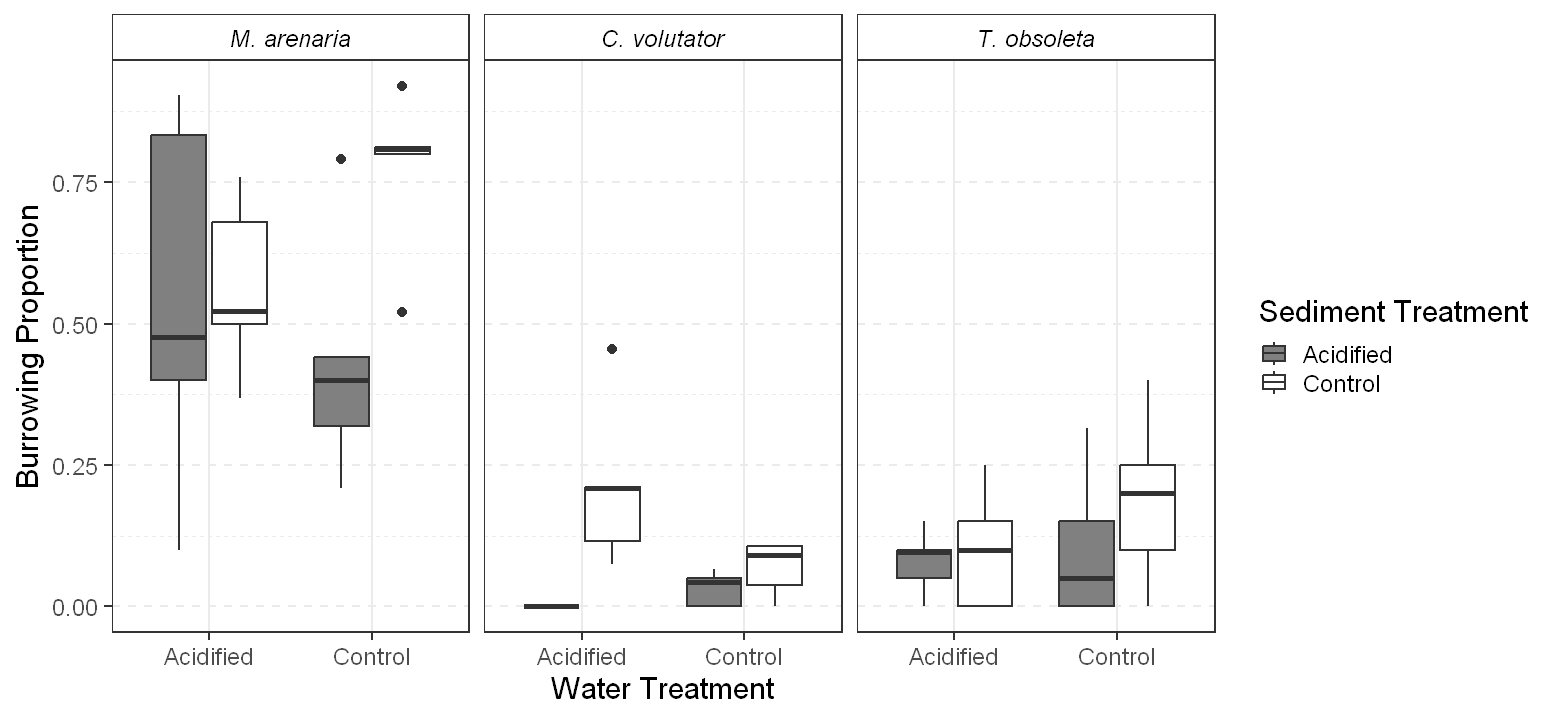

In [12]:
options(repr.plot.width = 13, repr.plot.height = 6)

# ── Figure: burrowing proportion by water × sediment treatment, 2017 ──────
p_bur17 <- ggplot(bur17b_comp, aes(x = Water, y = Burrow_prop, fill = Sediment)) +
    geom_boxplot() +
    xlab("Water Treatment") +
    ylab("Burrowing Proportion") +
    labs(fill = "Sediment Treatment") +
    facet_grid(. ~ Species, scales = "free",
               labeller = labeller(Species = Species.labs)) +
    scale_fill_grey(start = 0.5, end = 1.0) +
    theme_bw(base_size = 18) +
    theme(strip.background = element_rect(fill = "white"),
          strip.text = element_text(color = "black", face = "italic"))

p_bur17 + grids(axis = "y", linetype = "dashed")

In [13]:
# ── Assumption checks — 2017 burrowing ───────────────────────────────────
# Levene's test for homogeneity of variance; Shapiro-Wilk on model residuals
cat("=== Assumption checks — C. volutator 2017 ===\n")
lm_coro17 <- lm(Burrow_prop ~ Water * Sediment, data = bur17_coro)
cat("\nShapiro-Wilk (residuals):\n")
print(shapiro.test(lm_coro17$residuals))
cat("\nLevene's test:\n")
print(leveneTest(Burrow_prop ~ Water * Sediment, data = bur17_coro))

=== Assumption checks — C. volutator 2017 ===

Shapiro-Wilk (residuals):

	Shapiro-Wilk normality test

data:  lm_coro17$residuals
W = 0.79893, p-value = 0.0008328


Levene's test:
Levene's Test for Homogeneity of Variance (center = median)
      Df F value  Pr(>F)  
group  3  2.6778 0.08206 .
      16                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [14]:
# ── Two-way ANOVA: C. volutator 2017 ─────────────────────────────────────
cat("=== C. volutator 2017 — two-way ANOVA (Water × Sediment) ===\n")
bur17_coro_aov <- aov(Burrow_prop ~ Water * Sediment, data = bur17_coro)
print(car::Anova(bur17_coro_aov))

cat("\nTukey HSD:\n")
print(TukeyHSD(bur17_coro_aov, conf.level = 0.95))

cat("\nDescriptive statistics by treatment combination:\n")
bur17_coro$WaterSed <- paste(bur17_coro$Water, bur17_coro$Sediment, sep = "_")
bur17_coro %>%
    group_by(WaterSed) %>%
    summarise(mean = round(mean(Burrow_prop), 3),
              sd   = round(sd(Burrow_prop), 3),
              .groups = "drop") %>%
    print()

=== C. volutator 2017 — two-way ANOVA (Water × Sediment) ===
Anova Table (Type II tests)

Response: Burrow_prop
                 Sum Sq Df F value   Pr(>F)   
Water          0.015653  1  2.5007 0.133359   
Sediment       0.077615  1 12.3996 0.002833 **
Water:Sediment 0.038703  1  6.1831 0.024321 * 
Residuals      0.100152 16                    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey HSD:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Burrow_prop ~ Water * Sediment, data = bur17_coro)

$Water
                         diff        lwr        upr    p adj
Control-Acidified -0.05595218 -0.1309592 0.01905481 0.133359

$Sediment
                       diff        lwr       upr     p adj
Control-Acidified 0.1245916 0.04958461 0.1995986 0.0028332

$`Water:Sediment`
                                             diff         lwr           upr
Control:Acidified-Acidified:Acidified  0.03202899 -0.11113083  0.175188798

In [15]:
# ── Two-way ANOVA: T. obsoleta 2017 ──────────────────────────────────────
cat("=== T. obsoleta 2017 — two-way ANOVA (Water × Sediment) ===\n")
bur17_snail_aov <- aov(Burrow_prop ~ Water * Sediment, data = bur17_snail)
print(car::Anova(bur17_snail_aov))

=== T. obsoleta 2017 — two-way ANOVA (Water × Sediment) ===
Anova Table (Type II tests)

Response: Burrow_prop
                 Sum Sq Df F value Pr(>F)
Water          0.016276  1  1.1766 0.2941
Sediment       0.014525  1  1.0499 0.3208
Water:Sediment 0.005427  1  0.3923 0.5399
Residuals      0.221343 16               


In [16]:
# ── Two-way ANOVA: M. arenaria 2017 ──────────────────────────────────────
cat("=== M. arenaria 2017 — two-way ANOVA (Water × Sediment) ===\n")
bur17_clam_aov <- aov(Burrow_prop ~ Water * Sediment, data = bur17_clam)
print(car::Anova(bur17_clam_aov))

cat("\nDescriptive statistics by treatment combination:\n")
bur17_clam_desc <- bur17_clam
bur17_clam_desc$WaterSed <- paste(bur17_clam_desc$Water, bur17_clam_desc$Sediment, sep = "_")
bur17_clam_desc %>%
    group_by(WaterSed) %>%
    summarise(mean = round(mean(Burrow_prop), 3),
              sd   = round(sd(Burrow_prop), 3),
              .groups = "drop") %>%
    print()

=== M. arenaria 2017 — two-way ANOVA (Water × Sediment) ===
Anova Table (Type II tests)

Response: Burrow_prop
                Sum Sq Df F value  Pr(>F)  
Water          0.01132  1  0.2222 0.64374  
Sediment       0.16557  1  3.2505 0.09027 .
Water:Sediment 0.12608  1  2.4753 0.13521  
Residuals      0.81498 16                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Descriptive statistics by treatment combination:
# A tibble: 4 × 3
  WaterSed             mean    sd
  <chr>               <dbl> <dbl>
1 Acidified_Acidified 0.543 0.33 
2 Acidified_Control   0.566 0.155
3 Control_Acidified   0.432 0.22 
4 Control_Control     0.772 0.149


### Interpretation

In 2017, *C. volutator* showed a significant interaction between water and sediment treatments: the acidified water, control sediment combination produced approximately 14% higher burrowing than the remaining three treatment combinations. This pattern suggests that prior water column acidification conditionally influenced the burrowing response of amphipods to sediment pH, but only when sediment pH was not additionally reduced.

Neither *T. obsoleta* nor *M. arenaria* showed significant effects of water column acidification, sediment acidification, or their interaction on burrowing proportion in 2017.

## 6. Sediment Acidification — Burrowing Behaviour (2018)

The 2017 experiment was repeated in 2018 with a nested design (two header tanks per water treatment) to address the single-header-tank confound in 2017. Header tank nested within water treatment was included as a random effect in all 2018 models.

**Statistical approach:** Linear mixed effects models (Water \u00d7 Sediment, random = ~1|Rep) per species. Type III likelihood ratio tests via `car::Anova`.

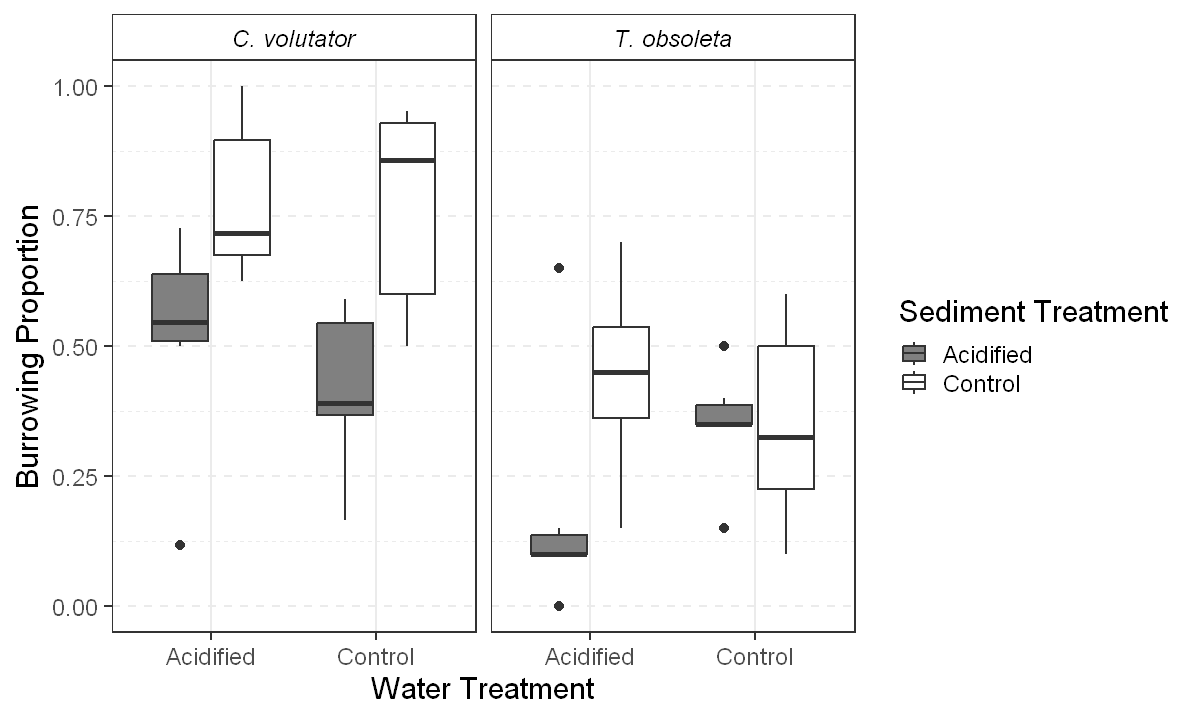

In [17]:
options(repr.plot.width = 10, repr.plot.height = 6)

# ── Figure: burrowing proportion by water × sediment treatment, 2018 ──────
p_bur18 <- ggplot(bur18b_comp, aes(x = Water, y = Burrow_prop, fill = Sediment)) +
    geom_boxplot() +
    xlab("Water Treatment") +
    ylab("Burrowing Proportion") +
    labs(fill = "Sediment Treatment") +
    facet_grid(. ~ Species, scales = "free",
               labeller = labeller(Species = Species.labs)) +
    scale_fill_grey(start = 0.5, end = 1.0) +
    theme_bw(base_size = 18) +
    theme(strip.background = element_rect(fill = "white"),
          strip.text = element_text(color = "black", face = "italic"))

p_bur18 + grids(axis = "y", linetype = "dashed")

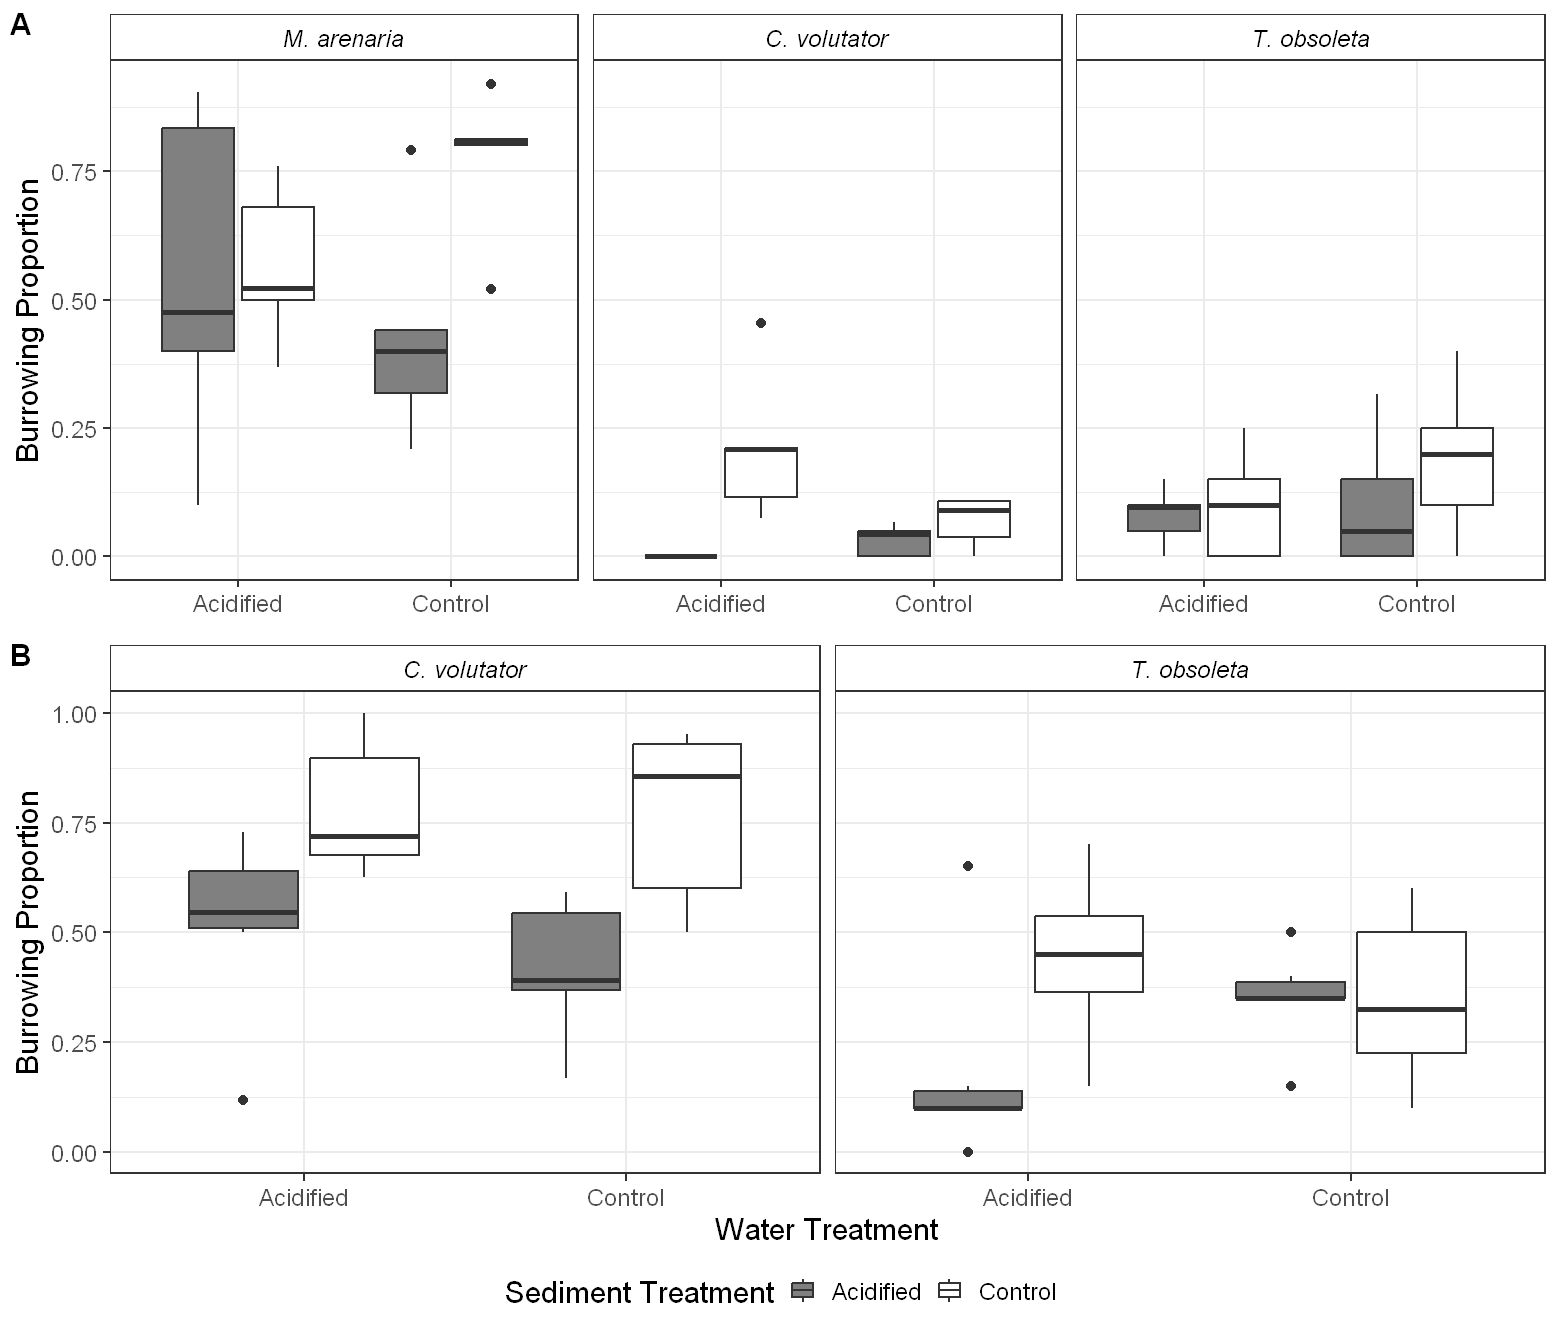

In [18]:
# ── Combined 2017/2018 figure (panel A/B) ────────────────────────────────
options(repr.plot.width = 13, repr.plot.height = 11)

ggarrange(
    p_bur17 + rremove("xlab"),
    p_bur18,
    labels     = c("A", "B"),
    ncol       = 1, nrow = 2,
    font.label = list(size = 18),
    common.legend = TRUE, legend = "bottom"
)

In [19]:
# ── LME: T. obsoleta 2018 (Water × Sediment, random = header tank) ───────
cat("=== T. obsoleta 2018 — linear mixed effects model ===\n")
bur18_snail.lme <- lme(Burrow_prop ~ Water * Sediment,
                       random    = ~1|Rep,
                       na.action = na.exclude,
                       data      = bur18_snail)
print(car::Anova(bur18_snail.lme, type = "3"))

cat("\nDescriptive statistics by sediment treatment:\n")
bur18_snail %>%
    group_by(Sediment) %>%
    summarise(mean = round(mean(Burrow_prop), 3),
              sd   = round(sd(Burrow_prop), 3),
              .groups = "drop") %>%
    print()

=== T. obsoleta 2018 — linear mixed effects model ===
Analysis of Deviance Table (Type III tests)

Response: Burrow_prop
                Chisq Df Pr(>Chisq)  
(Intercept)    5.7177  1    0.01680 *
Water          2.3627  1    0.12427  
Sediment       5.6763  1    0.01720 *
Water:Sediment 2.8382  1    0.09205 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Descriptive statistics by sediment treatment:
# A tibble: 2 × 3
  Sediment      mean    sd
  <fct>        <dbl> <dbl>
1 "Acidified " 0.267 0.196
2 "Control"    0.396 0.189


In [20]:
# ── LME: C. volutator 2018 (Water × Sediment, random = header tank) ──────
cat("=== C. volutator 2018 — linear mixed effects model ===\n")
bur18_coro.lme <- lme(Burrow_prop ~ Water * Sediment,
                      random    = ~1|Rep,
                      na.action = na.exclude,
                      data      = bur18_coro)
print(car::Anova(bur18_coro.lme, type = "3"))

cat("\nDescriptive statistics by sediment treatment:\n")
bur18_coro %>%
    group_by(Sediment) %>%
    summarise(mean = round(mean(Burrow_prop), 3),
              sd   = round(sd(Burrow_prop), 3),
              .groups = "drop") %>%
    print()

=== C. volutator 2018 — linear mixed effects model ===
Analysis of Deviance Table (Type III tests)

Response: Burrow_prop
                 Chisq Df Pr(>Chisq)    
(Intercept)    46.7278  1  8.157e-12 ***
Water           0.9049  1    0.34147    
Sediment        5.9932  1    0.01436 *  
Water:Sediment  0.3885  1    0.53307    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Descriptive statistics by sediment treatment:
# A tibble: 2 × 3
  Sediment      mean    sd
  <fct>        <dbl> <dbl>
1 "Acidified " 0.467 0.187
2 "Control"    0.776 0.174


### Interpretation

In 2018, sediment acidification significantly reduced burrowing in both *T. obsoleta* and *C. volutator*. Burrowing of *T. obsoleta* was reduced by approximately 13% in acidified sediment. Burrowing of *C. volutator* was reduced by approximately 30% in acidified sediment. Neither species showed a significant interaction between prior water column acidification and sediment treatment in 2018, nor a significant main effect of water treatment.

The consistency of the sediment acidification effect on *C. volutator* across both years (interaction in 2017; main effect in 2018) suggests that acidified sediment reliably suppresses amphipod burrowing, while the expression of that effect is modulated by prior water column conditions.

## 7. GABA\u2082 Experiment — Gabazine \u00d7 Sediment pH

This experiment tested whether disruption of GABA\u2082 receptors by the neuroinhibitor gabazine alters the burrowing response of invertebrates to reduced sediment pH. Animals were pre-exposed to gabazine (5 mg L\u207b\u00b9) or control seawater for 30 min before being placed in acidified or control sediment for 4 h.

**Species:** *Limecola balthica*, *C. volutator*, *T. obsoleta*  
**Design:** 2\u00d72 factorial (sediment pH \u00d7 gabazine presence), n\u2009=\u20095  
**Statistical approach:** Two-way ANOVA per species. Tukey post-hoc for significant effects.

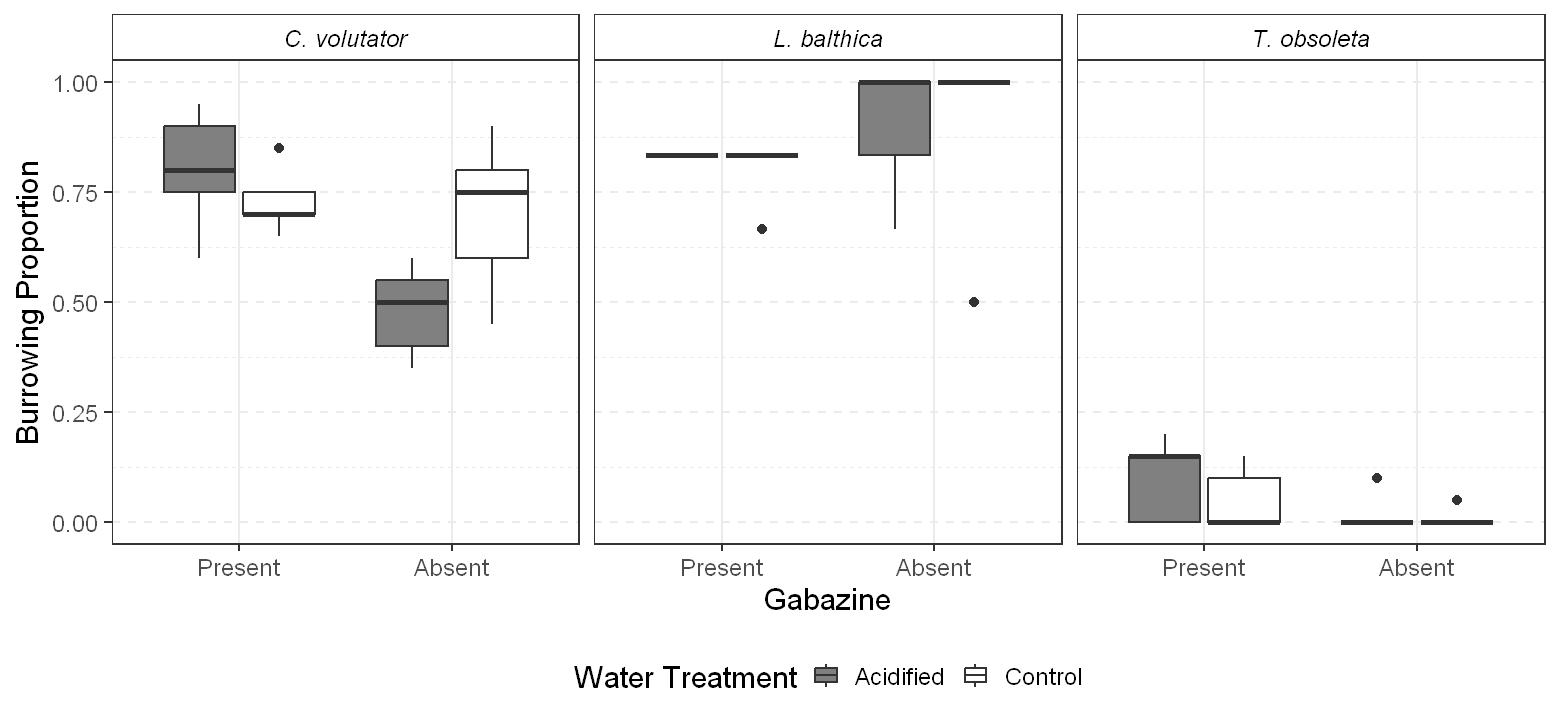

In [21]:
options(repr.plot.width = 13, repr.plot.height = 6)

# ── Figure: burrowing proportion by gabazine × water treatment, all species
p_gab <- ggplot(burgab_comp, aes(x = GabaPres, y = Burr_prop, fill = Water)) +
    geom_boxplot() +
    stat_boxplot() +
    xlab("Gabazine") +
    ylab("Burrowing Proportion") +
    labs(fill = "Water Treatment") +
    facet_wrap(. ~ Species, scales = "fixed",
               labeller = labeller(Species = Species.labs.mac)) +
    scale_x_discrete(limits = c("Y", "N"),
                     labels  = c("N" = "Absent", "Y" = "Present")) +
    scale_fill_grey(start = 0.5, end = 1.0) +
    theme_bw(base_size = 18) +
    theme(legend.position = "bottom",
          strip.background = element_rect(fill = "white"),
          strip.text = element_text(color = "black", face = "italic"))

p_gab + grids(axis = "y", linetype = "dashed")

In [22]:
# ── Assumption checks — C. volutator gabazine ────────────────────────────
cat("=== Assumption checks — C. volutator GABAA experiment ===\n")
lm_gab_coro <- lm(Burr_prop ~ Water * GabaPres, data = burgab_coro)
cat("\nShapiro-Wilk (residuals):\n")
print(shapiro.test(lm_gab_coro$residuals))
cat("\nLevene's test:\n")
print(leveneTest(Burr_prop ~ Water * GabaPres, data = burgab_coro))

=== Assumption checks — C. volutator GABAA experiment ===

Shapiro-Wilk (residuals):

	Shapiro-Wilk normality test

data:  lm_gab_coro$residuals
W = 0.97799, p-value = 0.9056


Levene's test:
Levene's Test for Homogeneity of Variance (center = median)
      Df F value Pr(>F)
group  3  0.8553 0.4841
      16               


In [23]:
# ── Two-way ANOVA: T. obsoleta — gabazine × water ────────────────────────
cat("=== T. obsoleta — gabazine × water ANOVA ===\n")
gab_snail_aov <- aov(Burr_prop ~ Water * GabaPres, data = burgab_snail)
print(car::Anova(gab_snail_aov))

=== T. obsoleta — gabazine × water ANOVA ===
Anova Table (Type II tests)

Response: Burr_prop
               Sum Sq Df F value  Pr(>F)  
Water          0.0045  1  1.1077 0.30822  
GabaPres       0.0180  1  4.4308 0.05145 .
Water:GabaPres 0.0020  1  0.4923 0.49298  
Residuals      0.0650 16                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [24]:
# ── Two-way ANOVA: L. balthica — gabazine × water ────────────────────────
cat("=== L. balthica — gabazine × water ANOVA ===\n")
gab_mac_aov <- aov(Burr_prop ~ Water * GabaPres, data = burgab_mac)
print(car::Anova(gab_mac_aov))

=== L. balthica — gabazine × water ANOVA ===
Anova Table (Type II tests)

Response: Burr_prop
                 Sum Sq Df F value Pr(>F)
Water          0.001389  1  0.0714 0.7927
GabaPres       0.034722  1  1.7857 0.2001
Water:GabaPres 0.001389  1  0.0714 0.7927
Residuals      0.311111 16               


In [25]:
# ── Two-way ANOVA: C. volutator — gabazine × water ───────────────────────
cat("=== C. volutator — gabazine × water ANOVA ===\n")
gab_coro_aov <- aov(Burr_prop ~ Water * GabaPres, data = burgab_coro)
print(car::Anova(gab_coro_aov))

cat("\nTukey HSD (significant interaction):\n")
print(TukeyHSD(gab_coro_aov, conf.level = 0.95))

cat("\nDescriptive statistics by water × gabazine combination:\n")
burgab_coro$WaterGaba <- paste(burgab_coro$Water, burgab_coro$GabaPres, sep = "_")
burgab_coro %>%
    group_by(WaterGaba) %>%
    summarise(mean = round(mean(Burr_prop), 3),
              sd   = round(sd(Burr_prop), 3),
              .groups = "drop") %>%
    print()

=== C. volutator — gabazine × water ANOVA ===
Anova Table (Type II tests)

Response: Burr_prop
                 Sum Sq Df F value   Pr(>F)   
Water          0.028125  1  1.6917 0.211795   
GabaPres       0.153125  1  9.2105 0.007884 **
Water:GabaPres 0.105125  1  6.3233 0.022988 * 
Residuals      0.266000 16                    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Tukey HSD (significant interaction):
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Burr_prop ~ Water * GabaPres, data = burgab_coro)

$Water
                   diff        lwr       upr     p adj
Control-Acidified 0.075 -0.0472397 0.1972397 0.2117954

$GabaPres
     diff       lwr       upr     p adj
Y-N 0.175 0.0527603 0.2972397 0.0078839

$`Water:GabaPres`
                         diff         lwr       upr     p adj
Control:N-Acidified:N    0.22 -0.01330911 0.4533091 0.0681281
Acidified:Y-Acidified:N  0.32  0.08669089 0.5533091 0.0059794
Contro

In [26]:
# ── Descriptive summary across all species × treatment combinations ───────
cat("=== All species — mean burrowing by species × water × gabazine ===\n")
burgab_comp %>%
    group_by(Species, Water, GabaPres) %>%
    summarise(
        n      = n(),
        mean   = round(mean(Burr_prop), 3),
        median = round(median(Burr_prop, na.rm = TRUE), 3),
        .groups = "drop"
    ) %>%
    print()

=== All species — mean burrowing by species × water × gabazine ===
# A tibble: 12 × 6
   Species   Water     GabaPres     n  mean median
   <fct>     <fct>     <fct>    <int> <dbl>  <dbl>
 1 Corophium Acidified N            5 0.48   0.5  
 2 Corophium Acidified Y            5 0.8    0.8  
 3 Corophium Control   N            5 0.7    0.75 
 4 Corophium Control   Y            5 0.73   0.7  
 5 Limecola  Acidified N            5 0.9    1    
 6 Limecola  Acidified Y            5 0.833  0.833
 7 Limecola  Control   N            5 0.9    1    
 8 Limecola  Control   Y            5 0.8    0.833
 9 Snail     Acidified N            5 0.02   0    
10 Snail     Acidified Y            5 0.1    0.15 
11 Snail     Control   N            5 0.01   0    
12 Snail     Control   Y            5 0.05   0    


### Interpretation

Gabazine had a significant interactive effect on burrowing in *C. volutator* only. In the acidified water treatment, the presence of gabazine increased the proportion of *C. volutator* individuals burrowed by approximately 30%, suggesting that GABA\u2082 receptor activation — suppressed by gabazine — normally inhibits burrowing under acidified conditions.

No significant effects of gabazine, water pH, or their interaction were detected for *T. obsoleta* or *L. balthica*, indicating that the GABA\u2082 mechanism identified in *C. volutator* is not a universal response across benthic invertebrate taxa.

This result provides the first experimental evidence that GABA\u2082 receptor disruption is involved in the mechanism by which sediment acidification affects burrowing behaviour in an intertidal invertebrate, and underscores the taxonomic specificity of neurochemical responses to ocean acidification.

## 8. Results Summary

### Key Findings

**Growth and survival (water column acidification):**  
Six weeks of reduced-pH water (\u0394pH \u2248 0.2 units) had minimal effects on growth and survival across species and years. The only significant effect was a reduction in shell length of *T. obsoleta* in 2017. No significant effects were detected for *M. arenaria* length, weight, or survival, or for *T. obsoleta* in 2018.

**Burrowing — sediment acidification:**  
Sediment acidification reduced burrowing in *T. obsoleta* (by \u224813%) and *C. volutator* (by \u224830%) in 2018. In 2017, *C. volutator* showed an interaction effect: prior exposure to acidified water increased burrowing in control sediment relative to other treatment combinations. *M. arenaria* burrowing was unaffected by either treatment in 2017.

**GABA\u2082 mechanism:**  
The GABA\u2082 neuroinhibitor gabazine restored burrowing of *C. volutator* in acidified water conditions, implicating GABA\u2082 receptor activation as the mechanism underlying the burrowing suppression response to acidification in this species. No gabazine effect was detected in *T. obsoleta* or *L. balthica*.

**Overall:** Results indicate substantial taxonomic variation in the burrowing and morphometric responses of benthic invertebrates to water column and sediment acidification, with *C. volutator* being the most consistently responsive species across experiments.

---

### Limitations and Caveats

**Single header tank (2017):** The 2017 water column acidification trial used one header tank per treatment, meaning that differences between water treatments in 2017 cannot be fully separated from header-tank-level variation. This was addressed by replicating the experiment in 2018 with a nested design.

**High *C. volutator* mortality:** Substantial mortality of *C. volutator* during the water column exposure period (\u224846\u201365% across treatments) meant that growth and survival data for this species could not be analysed, and that the animals entering the sediment acidification trials were a potentially biased survivor subset.

**Short burrowing assay duration:** Burrowing was assessed at a single time point. Dynamic burrowing trajectories — whether animals ultimately burrow given more time — could not be examined with this design.

**Laboratory conditions:** Animals were maintained on biofilm and algae under controlled temperature and salinity. Laboratory behaviour may not fully reflect field responses where animals are embedded in community interactions and natural pH variability.

**Gabazine concentration:** A single gabazine concentration (5 mg L\u207b\u00b9) was used. Dose\u2013response relationships and potential non-specific neurotoxic effects at this concentration were not evaluated.

---

**Full citation:** McGarrigle, S.A., Bishop, M.M., Dove, S.L., Hunt, H.L. (2023). Effects of sediment and water column acidification on growth, survival, burrowing behaviour, and GABA\u2082 receptor function of benthic invertebrates. *Journal of Experimental Marine Biology and Ecology*, 566, 151918. https://doi.org/10.1016/j.jembe.2023.151918